In [1]:
from typing import List
import json
from typing import Dict
from tabulate import tabulate
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List

In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
def read_jsonl_results(file_path: str) -> List[Dict]:
    with open(file_path, 'r') as f:
        data = json.load(f)

    results = {}
    for benchmark_name, benchmark_data in data.items():
        acc = benchmark_data[1]['metrics'][0]['accept_length']
        througput = benchmark_data[1]['metrics'][0]['output_throughput']
        results[benchmark_name] = {
            'acc': acc,
            'throughput': througput
        }

    return results

In [4]:
file_list = {
    'data/data-regeneration/llama3-8b-ealge-data-regen_results_20260106_085230.jsonl': "Llama3-8b-Eagle-Data-Regen",
    'data/data-regeneration/llama3-8b-ealge-no-data-regen_results_20260106_091640.jsonl': "Llama3-8b-Eagle-No-Data-Regen"   ,
    'data/data-regeneration/llama3-70b-ealge-data-regen_results_20260106_090043.jsonl': "Llama3-70b-Eagle-Data-Regen",
    'data/data-regeneration/llama3-70b-ealge-no-data-regen_results_20260106_093419.jsonl': "Llama3-70b-Eagle-No-Data-Regen"
}

In [5]:
acc_rows = []
throughput_rows = []
for file_path, name in file_list.items():
    results = read_jsonl_results(file_path)
    acc_rows.append(
        [
            name,
            results['mtbench']['acc'],
            results['gpqa']['acc'],
            results['financeqa']['acc'],
            results['math500']['acc'],
            results['gsm8k']['acc'],
            results['humaneval']['acc'],
            results['livecodebench']['acc'],
        ]
    )

    throughput_rows.append(
        [
            name,
            results['mtbench']['throughput'],
            results['gpqa']['throughput'],
            results['financeqa']['throughput'],
            results['math500']['throughput'],
            results['gsm8k']['throughput'],
            results['humaneval']['throughput'],
            results['livecodebench']['throughput'],
        ]
    )

In [6]:
# print the acc_rows
acc_table = tabulate(acc_rows, headers=['Model', 'MTBENCH', 'GPQA', 'FinanceQA', 'Math500', 'GSM8K', 'HumanEval', 'LiveCodeBench'], tablefmt='grid')
print(acc_table)

throughput_table = tabulate(throughput_rows, headers=['Model', 'MTBENCH', 'GPQA', 'FinanceQA', 'Math500', 'GSM8K', 'HumanEval', 'LiveCodeBench'], tablefmt='grid')
print(throughput_table)



+--------------------------------+-----------+---------+-------------+-----------+---------+-------------+-----------------+
| Model                          |   MTBENCH |    GPQA |   FinanceQA |   Math500 |   GSM8K |   HumanEval |   LiveCodeBench |
+================================+===========+=========+=============+===========+=========+=============+=================+
| Llama3-8b-Eagle-Data-Regen     |   2.91524 | 3.13108 |     1.97051 |   3.47455 | 2.50846 |     3.34511 |         3.13793 |
+--------------------------------+-----------+---------+-------------+-----------+---------+-------------+-----------------+
| Llama3-8b-Eagle-No-Data-Regen  |   2.78323 | 2.97909 |     1.83606 |   3.1408  | 2.66688 |     2.99754 |         2.95457 |
+--------------------------------+-----------+---------+-------------+-----------+---------+-------------+-----------------+
| Llama3-70b-Eagle-Data-Regen    |   2.96305 | 2.18855 |     2.2568  |   2.82979 | 2.30201 |     2.93474 |         2.9633  |


In [7]:
@dataclass
class BarPlotData:
    y: List[float]
    name: str

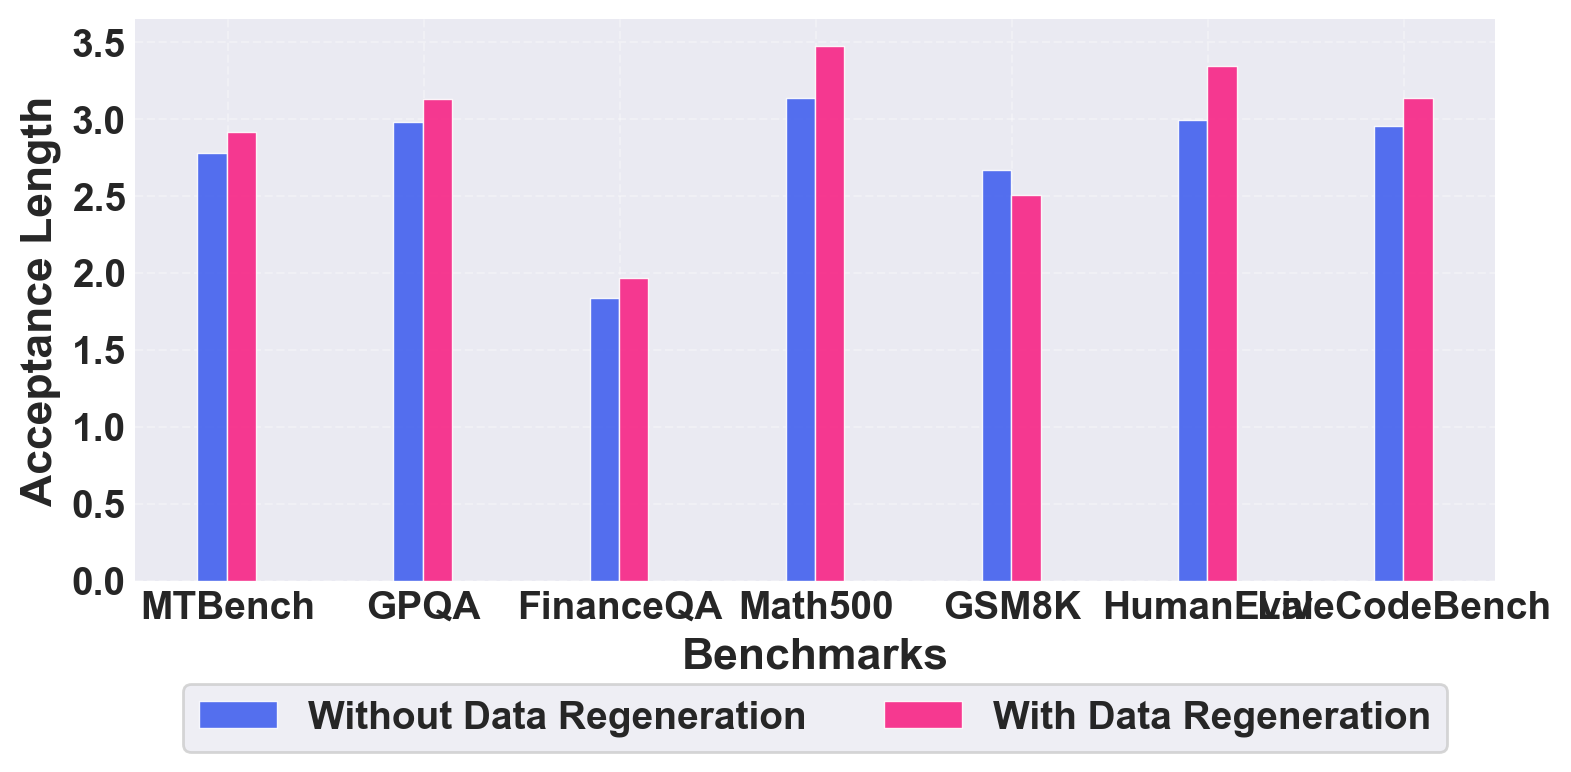

In [13]:
def get_field(result: Dict, field: str) -> float:
    return [
        result['mtbench'][field],
        result['gpqa'][field],
        result['financeqa'][field],
        result['math500'][field],
        result['gsm8k'][field],
        result['humaneval'][field],
        result['livecodebench'][field],
    ]

def generate_bar_plot(data_list: List[BarPlotData], x_label: str, y_label: str, title: str, x_ticks: List[str], show_legend: bool = True, show_grid: bool = True, num_legend_cols: int = 2):
    # compute the x point of each bar
    num_bars = len(data_list[0].y)
    num_data = len(data_list)
    
    plt.figure(figsize=(8, 4))
    
    # x = np.arange(num_bars)
    x = np.array([100, 200, 300, 400, 500, 600, 700])
    bar_width = 15

    for idx, data in enumerate(data_list):
        cur_x = x + (idx - num_data / 2) * bar_width + bar_width // 2
        plt.bar(
            x=cur_x, 
            height=data.y, 
            color=common.COLORS[idx], 
            edgecolor='white', 
            linewidth=0.5, 
            alpha=0.9, 
            width=bar_width,
            label=data.name
            )

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')

    if title:
        plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)

    if x_ticks:
        plt.xticks(x, x_ticks, fontsize=common.X_TICK_FONT_SIZE, fontweight='bold')
        plt.yticks(fontsize=common.Y_TICK_FONT_SIZE, fontweight='bold')

    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, prop={'weight': 'bold', 'size': 14}, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()


# Generate sample data
months = ['MTBench', 'GPQA', 'FinanceQA', 'Math500', 'GSM8K', 'HumanEval', 'LiveCodeBench']
data_list = [
        BarPlotData(y=acc_rows[1][1:], name='Without Data Regeneration'),
        BarPlotData(y=acc_rows[0][1:], name='With Data Regeneration'),
]


generate_bar_plot(
        data_list=data_list,
        x_label='Benchmarks',
        y_label='Acceptance Length',
        title=None,
        x_ticks=months,
        show_legend=True,
        show_grid=True,
        num_legend_cols=3
)
plt.savefig('plots/acceptance_of_llama3.1-8b_eagle3.pdf', dpi=300)
plt.show()

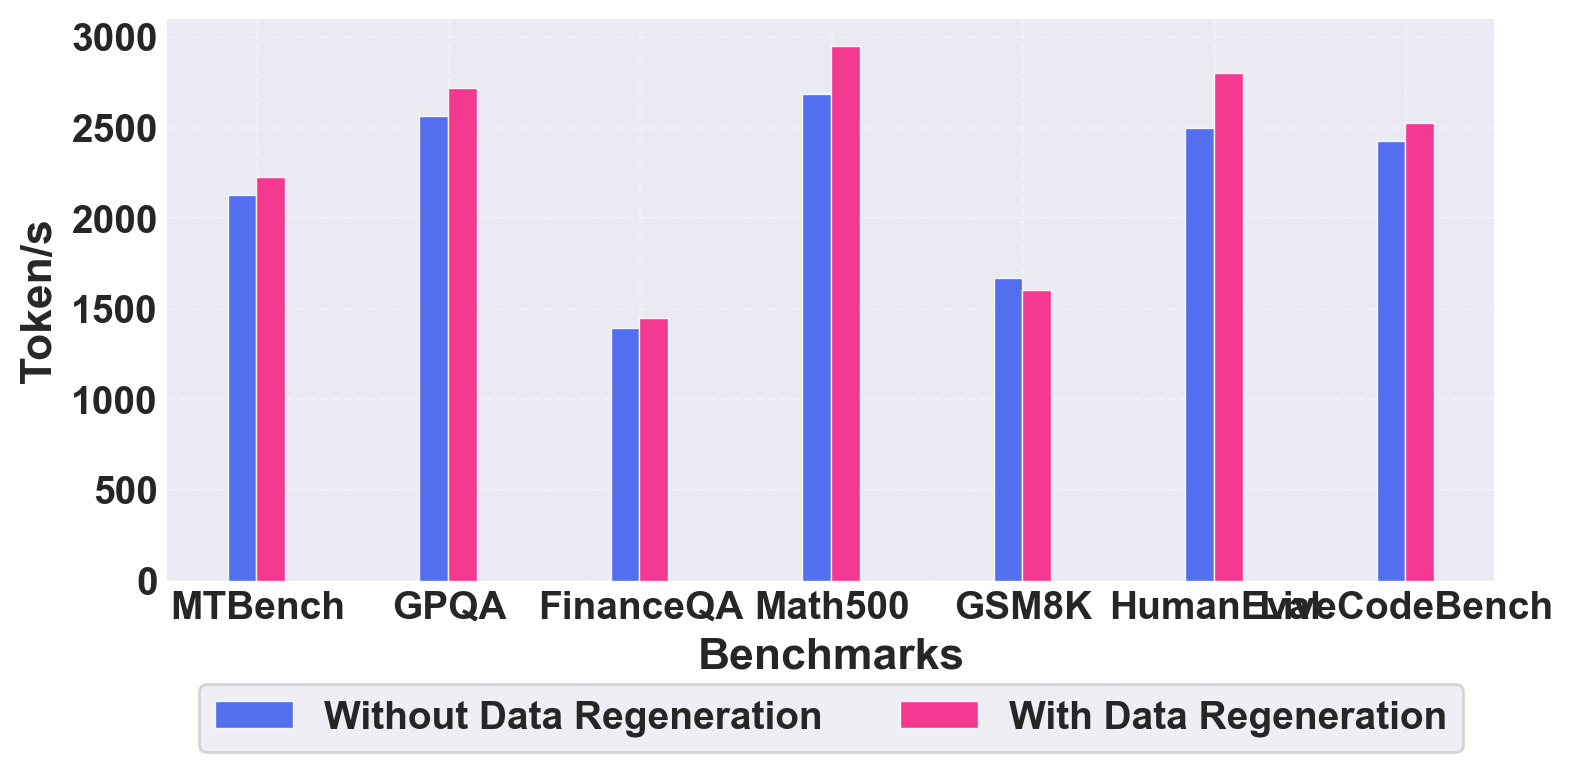

In [14]:
data_list = [
        BarPlotData(y=throughput_rows[1][1:], name='Without Data Regeneration'),
        BarPlotData(y=throughput_rows[0][1:], name='With Data Regeneration'),
]


generate_bar_plot(
        data_list=data_list,
        x_label='Benchmarks',
        y_label='Token/s',
        title=None,
        x_ticks=months,
        show_legend=True,
        show_grid=True,
        num_legend_cols=3
)
plt.savefig('plots/throughput_of_llama3.1-8b_eagle3.pdf', dpi=300)
plt.show()

In [10]:
speedup_list = []
for v1, v2 in zip(throughput_rows[1][1:], throughput_rows[0][1:]):
    speedup = v2 / v1
    speedup_list.append(speedup)

sum(speedup_list) / len(speedup_list)


1.0526892759487747